## Setup

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from src import load_b2c, test_statistic, ca, plot_heatmap, plot_scatter, plot_boxplot

### Load data

In [3]:
df_b2c = load_b2c()
df_b2c.categ = df_b2c.categ.astype(str)
df_b2c

,id_prod,date,session_id,client_id,sex,birth,price,categ,age,segment_client
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,f,1967,11.99,0,54,B2C
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,m,1960,19.37,0,61,B2C
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,m,1988,4.50,0,33,B2C
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,f,1989,6.55,0,32,B2C
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,f,1956,16.49,0,65,B2C
...,...,...,...,...,...,...,...,...,...,...
640729,1_508,2023-02-28 23:49:03.148402,s_348444,c_3573,f,1996,21.92,1,27,B2C
640730,2_37,2023-02-28 23:51:29.318531,s_348445,c_50,f,1994,48.99,2,29,B2C
640731,1_695,2023-02-28 23:53:18.929676,s_348446,c_488,f,1985,26.99,1,38,B2C
640732,0_1547,2023-02-28 23:58:00.107815,s_348447,c_4848,m,1953,8.99,0,70,B2C


## Corrélations

### Genre

#### Avec le catégorie

In [4]:
print(test_statistic(
    df=df_b2c,
    col1='sex',
    col2='categ'
))

🧩 Statistique Chi-2:  22.6686
🗽 Degrés de liberté: 2
🌊 Fréquences attendues:
[[201574.89662481 114822.13191434  17096.97146086]
 [185706.10337519 105782.86808566  15751.02853914]]

✅ Corrélation significative : on rejette H0 (p=1.20e-05 < 0.05)




##### Graphique

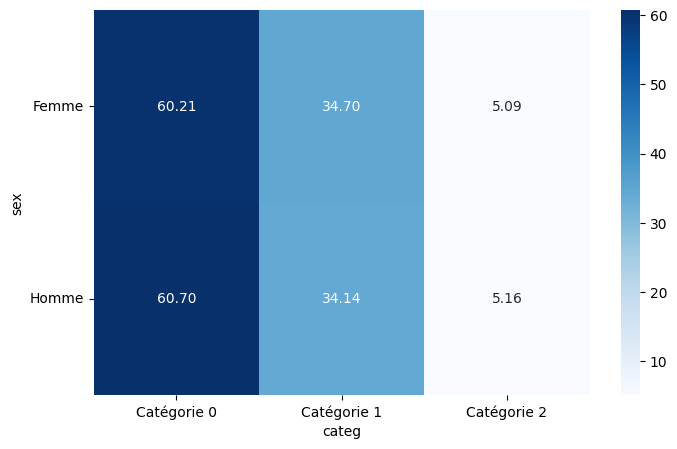

In [5]:
# normalize -> become percentage
df_heatmap = pd.crosstab(df_b2c['sex'], df_b2c['categ'], normalize='index') * 100
ax = plot_heatmap(
    df_heatmap,
    xlabel=['Catégorie 0', 'Catégorie 1', 'Catégorie 2'],
    ylabel=['Femme', 'Homme']
)

### Âge

In [6]:
df_par_client = df_b2c.groupby('client_id').agg(
    age=('age', 'mean'),
    montant_total=('price', 'sum'),
    panier_moyen=('price', 'mean'),
    frequence=('session_id', 'nunique')
).round(2)
df_par_client.age = df_par_client.age.round(0).astype(int)
df_par_client

,age,montant_total,panier_moyen,frequence
client_id,,,,
c_1,67,629.02,14.63,34
c_10,66,1353.60,23.34,34
c_100,29,254.85,31.86,5
c_1000,56,2291.88,18.19,94
c_1001,40,1823.85,17.71,47
...,...,...,...,...
c_995,66,189.41,13.53,9
c_996,52,1637.34,17.06,80
c_997,28,1490.01,25.25,24


#### Avec le montant total

In [7]:
print(test_statistic(
    df_par_client,
    col1='age',
    col2='montant_total'
))

🌈 Test de Shapiro-Wilk - age : stat =  0.9704
⚠️ Échantillonnage à 5000 observations (n original = 8596)
❌ Les données ne suivent pas une distribution normale : on rejette H0 (p=6.49e-31 < 0.05)

🌈 Test de Shapiro-Wilk - montant_total : stat =  0.9061
⚠️ Échantillonnage à 5000 observations (n original = 8596)
❌ Les données ne suivent pas une distribution normale : on rejette H0 (p=3.68e-48 < 0.05)

🎮 Coefficient de corrélation de Spearman: -0.1775
✅ Corrélation significative : on rejette H0 (p=8.28e-62 < 0.05)




##### Graphique

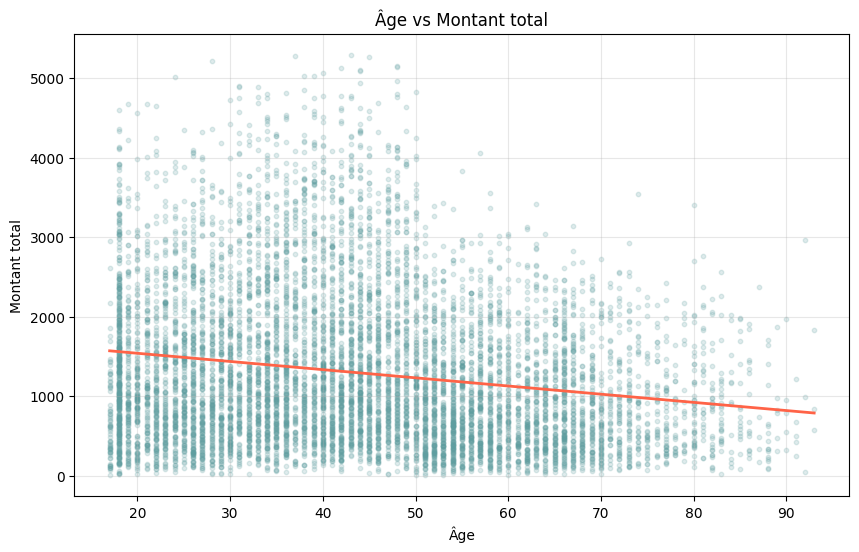

In [8]:
ax = plot_scatter(
    df_par_client,
    col_x='age',
    col_y='montant_total',
    title="Âge vs Montant total"
)
ax.set_xlabel("Âge")
ax.set_ylabel("Montant total")
plt.show()

#### Avec la fréquence d’achat

In [9]:
print(test_statistic(
    df_par_client,
    col1='age',
    col2='frequence'
))

🌈 Test de Shapiro-Wilk - age : stat =  0.9704
⚠️ Échantillonnage à 5000 observations (n original = 8596)
❌ Les données ne suivent pas une distribution normale : on rejette H0 (p=6.49e-31 < 0.05)

🌈 Test de Shapiro-Wilk - frequence : stat =  0.8577
⚠️ Échantillonnage à 5000 observations (n original = 8596)
❌ Les données ne suivent pas une distribution normale : on rejette H0 (p=2.46e-55 < 0.05)

🎮 Coefficient de corrélation de Spearman:  0.2185
✅ Corrélation significative : on rejette H0 (p=1.93e-93 < 0.05)




##### Graphique

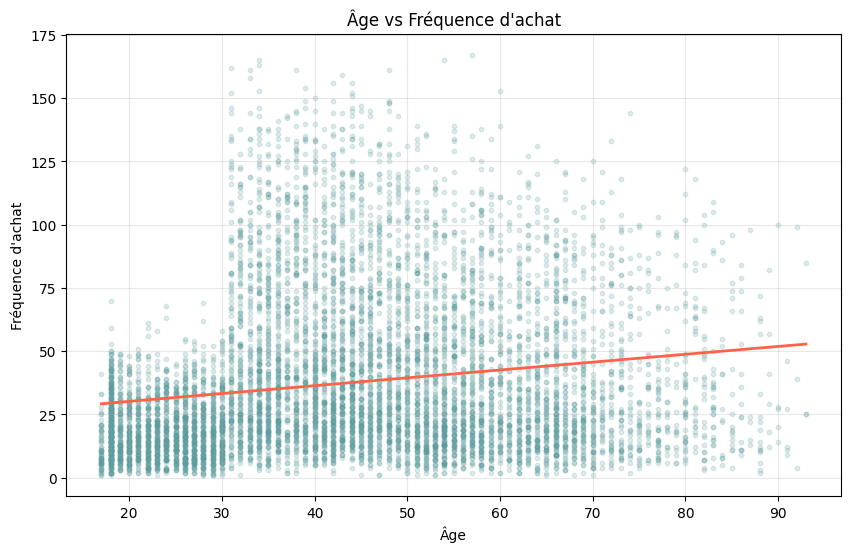

In [10]:
ax = plot_scatter(
    df_par_client,
    col_x='age',
    col_y='frequence',
    title="Âge vs Fréquence d'achat"
)
ax.set_xlabel("Âge")
ax.set_ylabel("Fréquence d'achat")
plt.show()

#### Avec le panier moyen

In [11]:
print(test_statistic(
    df_par_client,
    col1='age',
    col2='panier_moyen'
))
df_par_client

🌈 Test de Shapiro-Wilk - age : stat =  0.9704
⚠️ Échantillonnage à 5000 observations (n original = 8596)
❌ Les données ne suivent pas une distribution normale : on rejette H0 (p=6.49e-31 < 0.05)

🌈 Test de Shapiro-Wilk - panier_moyen : stat =  0.6828
⚠️ Échantillonnage à 5000 observations (n original = 8596)
❌ Les données ne suivent pas une distribution normale : on rejette H0 (p=1.28e-70 < 0.05)

🎮 Coefficient de corrélation de Spearman: -0.3255
✅ Corrélation significative : on rejette H0 (p=2.37e-211 < 0.05)




,age,montant_total,panier_moyen,frequence
client_id,,,,
c_1,67,629.02,14.63,34
c_10,66,1353.60,23.34,34
c_100,29,254.85,31.86,5
c_1000,56,2291.88,18.19,94
c_1001,40,1823.85,17.71,47
...,...,...,...,...
c_995,66,189.41,13.53,9
c_996,52,1637.34,17.06,80
c_997,28,1490.01,25.25,24


##### Graphique

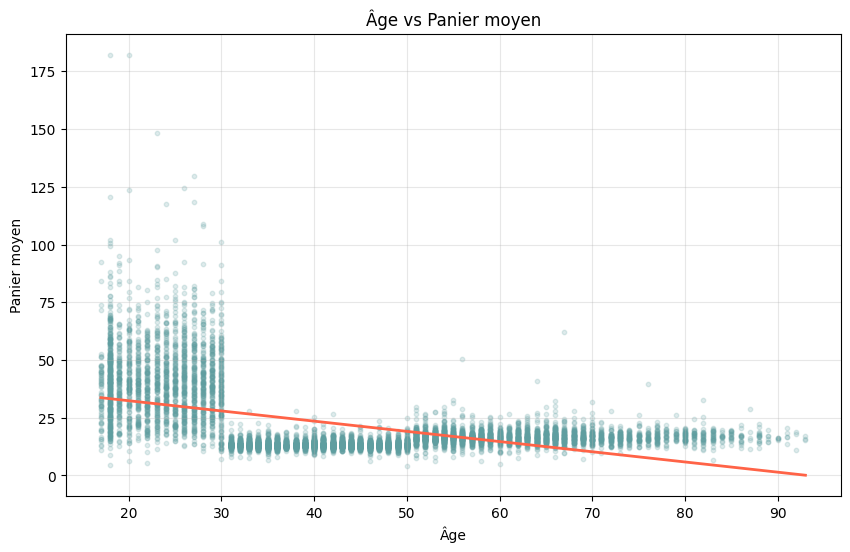

In [12]:
ax = plot_scatter(
    df_par_client,
    col_x='age',
    col_y='panier_moyen',
    title="Âge vs Panier moyen"
)
ax.set_xlabel("Âge")
ax.set_ylabel("Panier moyen")
plt.show()

#### Avec le catégorie

In [13]:
print(test_statistic(
    df_b2c,
    col1='age',
    col2='categ'
))

🎹 Test de ANOVA
💭 Statistique de test F: 39585.5108
✅ Différence significative entre les groupes : on rejette H0 (p=0.00e+00 < 0.05)

η²=0.1100 : Effet moyen



##### Graphique

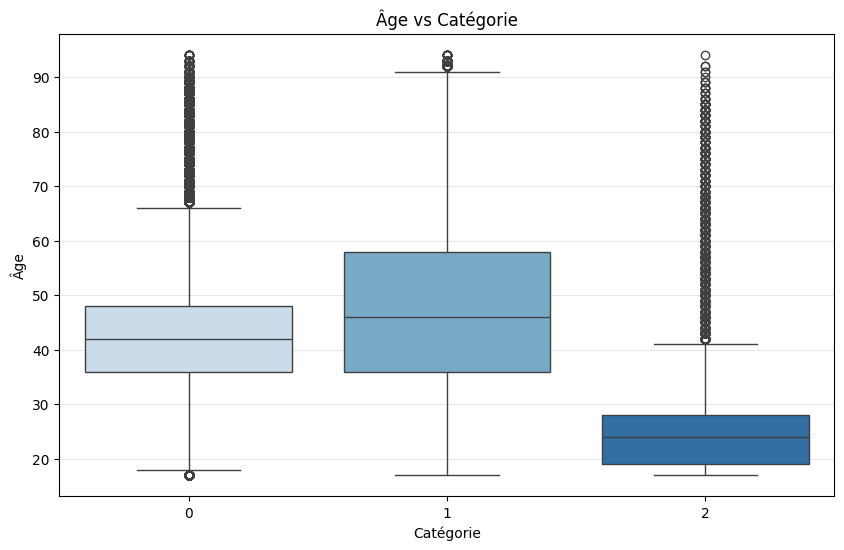

In [14]:
ax = plot_boxplot(
    df_b2c,
    col_x='categ',
    col_y='age',
    title="Âge vs Catégorie"
)
ax.set_xlabel("Catégorie")
ax.set_ylabel("Âge")
plt.show()